# Name: Galih
Add anything else for indentification/or however you want to label this notebook up here before submitting. 

# Submission
You do not need to write up a separate report since there will be space for you to write down thoughts/answer questions throughout this notebook. Instead, when you are finished, go to File --> Save and Export Notebook As --> LaTeX (or as pdf, but this option hasn't been working). This will convert the notebook to a .tex file which can be uploaded into Overleaf and compiled into an already formatted pdf. 

# Introduction
This homework goes over the concepts of calculating $\chi^{2}$ and reduced $\chi^{2}$ to see the goodness of fit of a model to provided data. We then implement an offshoot of this through Markov Chain Monte Carlo (MCMC) Simulations, which use a maximum log-likelihood to judge goodness of fit. It is important to note that maximizing log-likelihood is the same as minimizing chi-squared.

Please watch the following videos, then start filling in the below notebook cells to complete the problems.

Required videos to watch:
1. An introduction to $\chi^{2}$ and reduced $\chi^{2}$: https://www.youtube.com/watch?v=KNLhep3UZ68
2. An introduction to the background of MCMC Simulations: https://www.youtube.com/watch?v=nndtTssgtZE

Optional supplemental materials to read for $\chi^{2}$ and MCMC:
1. https://events.mpifr-bonn.mpg.de/indico/event/30/material/slides/12.pdf - Read sections 2.3-2.4 and 3
2. https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial_Solution.html - Implementation of MCMC

Chi Squared
-
Equation for it:
$$\chi^{2} = \sum_{i=1}^{N}{\frac{(y_{i}^{OBS}-y_{i}^{MOD})^{2}}{\epsilon_{y_{i}}^{2}}}$$
where $y_{i}^{OBS}$ are the data/observations with error estimation $\epsilon_{y_{i}}$, and $y_{i}^{MOD}$ is the model function.

Reduced Chi-Squared
-
Another important value is the number of degrees of freedom in the model, $\nu$, defined as 
$$\nu = n - p$$
where $n$ is the number of datapoints (measurements) and $p$ are the number of fitted parameters. 

With this, we can determine how well the model has fit the data by using the reduced $\chi^{2}_{\nu}$ which is defined as the chi-square per degree of freedom:

$$\chi^{2}_{\nu} = \frac{\chi^{2}}{\nu}$$

To determine how well the model has fit the data, we use the reduced $\chi^{2}_{\nu}$:
- $\chi^{2}_{\nu} < 1 \rightarrow$ over-fitting of the data
- $\chi^{2}_{\nu} > 1 \rightarrow$ poor model fit
- $\chi^{2}_{\nu} \simeq 1 \rightarrow$ good match between data and model in accordance with the data error

Taken from: https://events.mpifr-bonn.mpg.de/indico/event/30/material/slides/12.pdf (Section 2.3)

In [1]:
#Import necessary packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

## Simple power law [0.5 pts]

To get started, run the cell below. It's some fake noisy data that forms a power law to help ensure that your code is working. Feel free to change the parameters. The model for this problem is the power law which takes the functional form
$$y = Ax^{k}$$
where $A$ is a constant and $k$ is the exponent (or power law index). 

The goal is to explore how $\chi^{2}$ explores the parameter space for two parameters (A and k) by making a brute force $\chi^{2}$ algorithm. 

In [2]:
np.random.seed(42) #just so I get the same values as I repeat the procedure as a check to make sure things work

#power law params
A = 5        
k = -1.7
n = 100
p = 2
x = np.linspace(1, 100, n) #range of x values 
y_true = A*x**k #eqn without noise

noise = np.random.normal(0, 0.20 * y_true) #noise 

y = y_true + noise #the equation I want the model to fit to
y_err = 0.2*y_true #just some errors - they are Gaussian!

The first thing to do is make some functions for the model, $\chi^{2}$, and $\chi^{2}_{\nu}$.

In [3]:
# Define functions
def func(x,A,k):
    return A * x**k
def chi_sqr(y,y_true,y_err):
    return np.sum( (y - y_true)**2 / y_err**2)
def red_chi_sqr(chi, n, p):
    return chi / (n - p)

### Two Parameter Fit [2 pts]
Start with the two parameter fit in which for each combination of $A$ and $k$, a $\chi^{2}$ and $\chi^{2}_{\nu}$ is computed. Print out some of these values for a few of the iterations to see how they change. What do you notice? Hint: Define a grid of values for $\chi^{2}$ to search through. 


Note: This is a brute force method that explores the whole defined parameter space. It does not try to get the lowest-chi squre value.

In [13]:
# Two param fit
A_grid = np.linspace(3,7,200)
k_grid = np.linspace(-1,-3,200)
chi_grid = np.zeros((len(A_grid), len(k_grid)))

for i, A in enumerate(A_grid):
    for j, k in enumerate(k_grid):
        y_model = func(x, A, k)
        chi = chi_sqr(y, y_model, y_err)
        chi_grid[i, j] = chi

print(chi_grid[0:4, 0:4])

[[198055.04877543 180447.13567641 164346.61569963 149626.7797292 ]
 [200980.5776479  183124.17918143 166795.91661697 151867.35768962]
 [203927.60583232 185820.98476843 169263.3840568  154124.6366472 ]
 [206896.13332867 188537.55243741 171749.01801912 156398.61660195]]


Comments: The value of $\chi^2$ changes as we move between points inside the grid. There is a small trend, either horizontally or vertically in the grid, where the $\chi^2$ increases or decreases. 

Now, find and report the lowest value of $\chi^{2}_{\nu}$ and the corresponding $\chi^{2}$, $A$, and $k$. These are your best fit parameters. 

In [14]:
# Get the best values - The printed output is fine
min_idx = np.unravel_index(np.argmin(chi_grid), chi_grid.shape)
best_A = A_grid[min_idx[0]]
best_k = k_grid[min_idx[1]]
min_chi = chi_grid[min_idx]

best_red_chi = red_chi_sqr(min_chi, n, p)

print(f"Best A: {best_A:.5f}")
print(f"Best k: {best_k:.5f}")
print(f"Min chi^2: {min_chi:.5f}")
print(f"Reduced chi^2: {best_red_chi:.5f}")

Best A: 4.94975
Best k: -1.70352
Min chi^2: 81.58420
Reduced chi^2: 0.83249


Plot the data, model with the best-fit parameters, and residuals in log-log space (You should see a line). Comment on the fit.

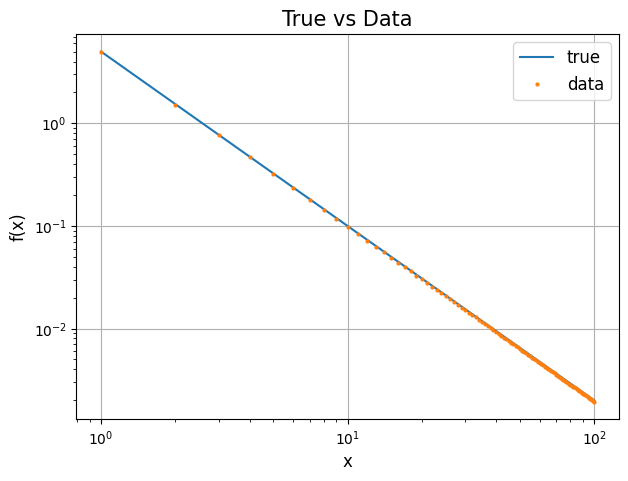

In [15]:
# Plot in loglog - You should see a line

plt.figure(figsize=(7,5))
plt.plot(x, y_true, color='tab:blue', label='true')
plt.plot(x, func(x,best_A,best_k), 'o', ms=2, color='tab:orange', label='data')
plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=12)
plt.xlabel('x', size=12)
plt.ylabel('f(x)', size=12)
plt.xticks(size=10)
plt.yticks(size=10)
plt.title('True vs Data',size=15)
plt.grid()

Comments: The chosen value of A and k shows that it has the smallest $\chi^2$. Based on the plot, we can also conclude that it is indeed the smallest one, since there is no major gap between the data and the model. Therefore, it is confirmed that the model fits the data. Also, the value of $\chi_\nu^2$ shows an indication that the model is quite good, even though according the criteria, less than 1 is overfit. 

We can also see how how $\chi^{2}$ changes as it cycles through the different combinations of parameters. To do this, make a contour plot of $A$ vs $k$ with a colorbar indicating $\chi^{2}$. Include a point indicating your best fit parameters. Comment on the parameter space in relation to thest best-fit values.

Hint: Use LogNorm for the colorbar. The plot should look choppy if you have a low grid resolution, which is fine. If you want, you can make a finer grid, but that will very quickly make the $\chi^{2}$ search become more computationally expensive. 

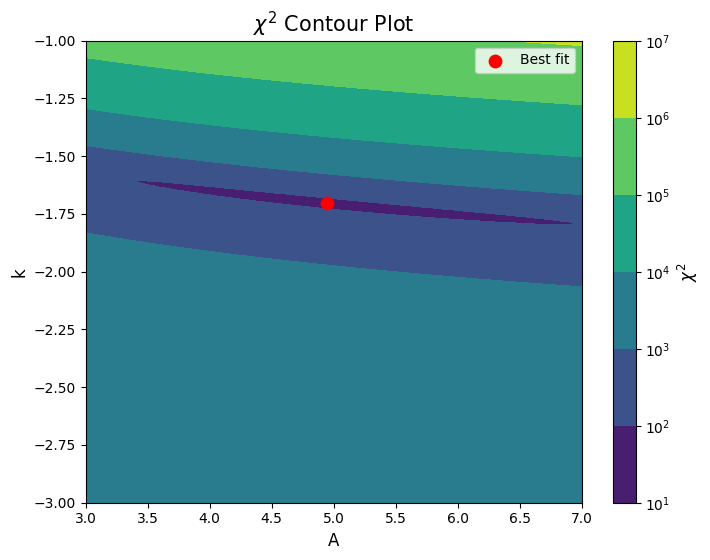

In [17]:
# Contour plot
A_mesh, k_mesh = np.meshgrid(A_grid, k_grid, indexing='ij')

plt.figure(figsize=(8,6))

# Filled contour with logarithmic color scaling
contourf = plt.contourf(A_mesh, k_mesh, chi_grid, levels=50, norm=LogNorm(), cmap='viridis')

# Add colorbar
cbar = plt.colorbar(contourf)
cbar.set_label(r'$\chi^2$', fontsize=12)

# overlay contour lines
#contours = plt.contour(A_mesh, k_mesh, chi_grid, levels=20, colors='black', linewidths=0.5)
#plt.clabel(contours, inline=True, fontsize=8)

# Mark best-fit point
plt.scatter(best_A, best_k, color='red', s=80, label='Best fit')

plt.xlabel('A',size=12)
plt.ylabel('k',size=12)
plt.xticks(size=10)
plt.yticks(size=10)
plt.title(r'$\chi^2$ Contour Plot',size=15)
plt.legend()

Comments: By exploring all the points in the grid, the algorithm found the best value of $\chi^2$, which is located roughly at the center of the grid (from countour plot). The trend that I mentioned earlier is the "slope" of $\chi^2$, centered at the best value. It shows that only a small region in the grid where it can produce the $\chi^2$ within the range of 10 to 100. 

## Real Data [2 pts]
Now let's apply what we've done from before to some real data. Download Stellar_Data.txt which holds mass ($M_{\odot}$), log stellar age (log years), log accretion rate (log $M_{\odot}/yr$), and log accretion rate errors. Note: The data is already in log scale, so how will that change your model function?

In [20]:
# Load in the data
data = np.loadtxt("HW07_Stellar_Data.txt", skiprows=1)
Mstar, logAge, logMacc, logMaccErr = data.T
logMstar = np.log10(Mstar)

In [22]:
# New model function here
# Mdot: accretion rate
def model_1(logAge,A,k):
    # Mdot = A * M**k
    # log Mdot = log A + k log M
    # x -> log Age, y -> log Mdot
    logMdot = A + k * logAge
    return logMdot

def model_2(logMstar,A,k):
    # Mdot = A * M**k
    # log Mdot = log A + k log M
    # x -> log Age, y -> log Mdot
    logMdot = A + k * logMstar
    return logMdot

Use the brute force method for two parameters from before. Play around with your parameter space and print out some parameters with their $\chi^{2}$, and $\chi^{2}_{\nu}$. Comment on what you notice about these values.

In [52]:
# Brute force method
A_grid2 = np.linspace(-10, 0, 200)
k_grid2 = np.linspace(-3, 3, 200)
chi_grid2_age = np.zeros((len(A_grid2), len(k_grid2)))
chi_grid2_mass = np.zeros((len(A_grid2), len(k_grid2)))

#Mstar, logAge, logMacc, logMaccErr

#model(logAge,A,k):
# chi-square loop
for i, A in enumerate(A_grid2):
    for j, k in enumerate(k_grid2):
        #y_model = A + k * logAge
        y_model = model_1(logAge,A,k)
        chi2 = chi_sqr(logMacc, y_model, logMaccErr)
        chi_grid2_age[i, j] = chi2

print(chi_grid2_age[0:4, 0:4])


min_idx2_age = np.unravel_index(np.argmin(chi_grid2_age), chi_grid2_age.shape)
best_A2_age = A_grid2[min_idx2_age[0]]
best_k2_age = k_grid2[min_idx2_age[1]]
min_chi2_age = chi_grid2_age[min_idx2_age]


n2 = len(logMacc)
p2 = 2
red_chi2_age = min_chi2_age / (n2 - p2)

[[11109477.74888844 10907141.73392728 10706666.70131789 10508052.65106026]
 [11057370.87786057 10855511.49262259 10655513.08973639 10457375.66920195]
 [11005387.3934503  10804004.63793552 10604482.8647725  10406822.07396125]
 [10953527.29565765 10752621.16986605 10553576.02642622 10356391.86533816]]


Comments: It shows a similar trend with the previous one, which is a slope of increasing or decreasing. 

Now, find and report the lowest value of $\chi^{2}_{\nu}$ and the corresponding parameters and $\chi^{2}$. These are your best fit parameters.

In [53]:
# Best-fit params
#print("Best A  | Best k  | Min chi^2 | Reduced chi^2")
#print(f"{best_A2_age:.4f} | {best_k2_age:.4f} | {min_chi2_age:.4f} | {red_chi2_age:.4f}")
print(f"Best A: {best_A2_age:.5f}")
print(f"Best k: {best_k2_age:.5f}")
print(f"Min chi^2: {min_chi2_age:.5f}")
print(f"Reduced chi^2: {red_chi2_age:.5f}")

Best A: -5.82915
Best k: -0.34673
Min chi^2: 4066.73746
Reduced chi^2: 17.52904


As before, plot the data with errors, model with the best-fit parameters, and residuals in log-log space. Make sure to include units on the plot. Comment on the fit. Look back at $\chi^{2}_{\nu}$ value you got, what does this value mean for your model? How could one improve $\chi^{2}_{\nu}$? 

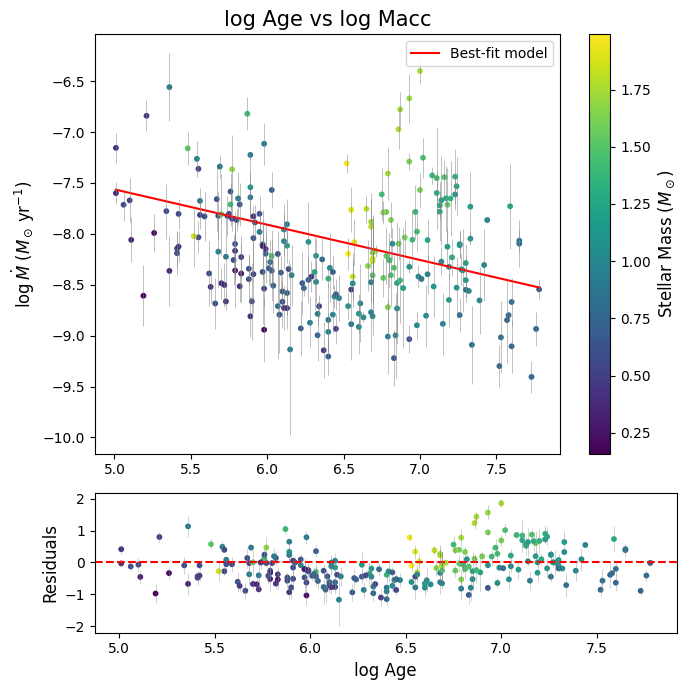

In [54]:
# Plot it up
logAge_model = np.linspace(np.min(logAge), np.max(logAge), 200)
logMacc_model = best_A2_age + best_k2_age * logAge_model

# Residuals
model_data = best_A2_age + best_k2_age * logAge
residuals = logMacc - model_data

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7,7), gridspec_kw={'height_ratios': [3, 1]})

# Top panel: main scatter
sc = ax1.scatter(logAge, logMacc, c=Mstar, s=10, cmap='viridis')
ax1.plot(logAge_model, logMacc_model, color='red', label='Best-fit model')
ax1.errorbar(logAge, logMacc, yerr=logMaccErr, fmt='none', ecolor='gray', elinewidth=0.5, alpha=0.7)

ax1.set_ylabel(r'$\log \dot{M}\ (M_\odot\,\mathrm{yr}^{-1})$', fontsize=12)
ax1.set_title('log Age vs log Macc', fontsize=15)
ax1.legend(loc='upper right')

cbar = fig.colorbar(sc, ax=ax1)
cbar.set_label(r'Stellar Mass ($M_\odot$)', fontsize=12)

# Bottom panel: residuals 
ax2.scatter(logAge, residuals, c=Mstar, s=10, cmap='viridis')
ax2.axhline(0, color='red', linestyle='--')

ax2.set_xlabel('log Age', fontsize=12)
ax2.set_ylabel('Residuals', fontsize=12)

ax2.errorbar(logAge, residuals, yerr=logMaccErr, fmt='none', ecolor='gray', elinewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

Comments

Answers: The value of $\chi^2$ is huge for this case, as well as for $\chi_\nu^2$ which has value of more than 1. More than 1 means that the model is poor for this data, so that another model is needed to better represent the variables. \
To improve $\chi_\nu^2$, according to its formula, one thing we can possibly do is to increase the number of data. However, this will come at a cost of computational time because the algorithm needs to scan more points. 

Also, make the contour plot of parameter 1 vs parameter 2 with a colorbar indicating $\chi^{2}$ again. Add the point indicating your best-fit parameters. Comment on the parameter space in relation to these best-fit values. 

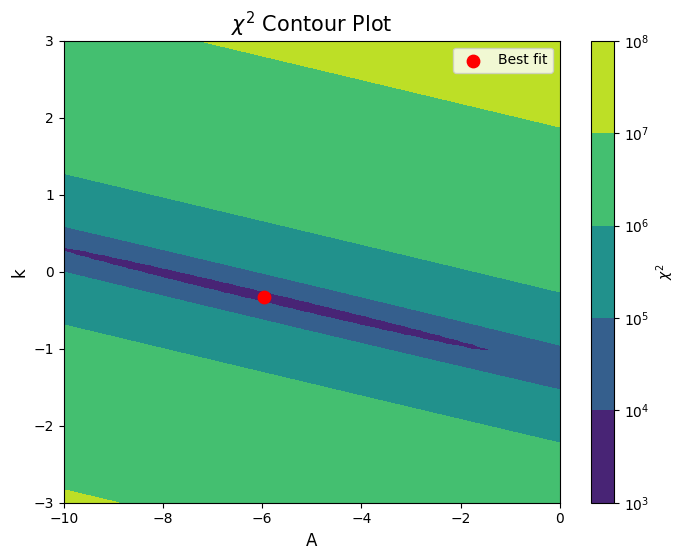

In [148]:
# Contour plot
A_mesh2, k_mesh2 = np.meshgrid(A_grid2, k_grid2, indexing='ij')

plt.figure(figsize=(8,6))

# Filled contour with logarithmic color scaling
contourf = plt.contourf(A_mesh2, k_mesh2, chi_grid2_age, levels=50, norm=LogNorm(), cmap='viridis')

# Add colorbar
cbar = plt.colorbar(contourf)
cbar.set_label(r'$\chi^2$')

# overlay contour lines
#contours = plt.contour(A_mesh2, k_mesh2, chi_grid2_age, levels=20, colors='black', linewidths=0.5)
#plt.clabel(contours, inline=True, fontsize=8)

# Mark best-fit point
plt.scatter(best_A2_age, best_k2_age, color='red', s=80, label='Best fit')

plt.xlabel('A', fontsize=12)
plt.ylabel('k', fontsize=12)
plt.xticks(size=10)
plt.yticks(size=10)
plt.title(r'$\chi^2$ Contour Plot', fontsize=15)
plt.legend()


Comments: Even tough we already know that the model is bad for this case, the algorithm still shows a convergence towards the smallest $\chi^2$ in the grid points.

# Fitting Stellar Accretion [5.5 pts]

In this part we are going to be using the the emcee package to run MCMC on a data set for stellar accretion
https://emcee.readthedocs.io/en/stable/

We will work through the steps in https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial_Solution.html to set up the MCMC.

In [28]:
import emcee

First, load Stellar_Data.txt into the notebook and make a scatter plot of logAge vs logMacc. Note: the data is already logarithmic. [0.5 pts]

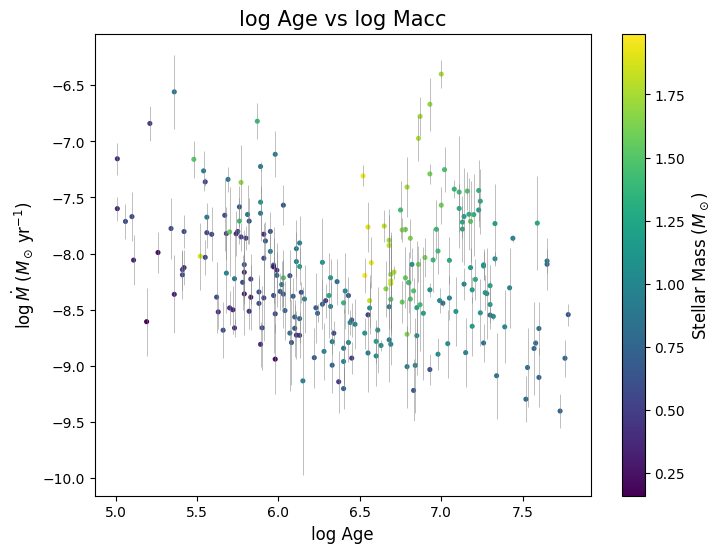

In [30]:
# Load data and plot
#Mstar, logAge, logMacc, logMaccErr
plt.figure(figsize=(8,6))

sc = plt.scatter(logAge, logMacc, c=Mstar, s=7, cmap='viridis')
plt.errorbar(logAge, logMacc, yerr=logMaccErr, fmt='none', ecolor='gray', elinewidth=0.5, alpha=0.7)

plt.xlabel('log Age', fontsize=12)
plt.ylabel(r'$\log \dot{M}\ (M_\odot\,\mathrm{yr}^{-1})$', size=12)
plt.xticks(size=10)
plt.yticks(size=10)
plt.title('log Age vs log Macc', fontsize=15)

cbar = plt.colorbar(sc)
#cbar.set_label(r'log $M_\star$ ($M_\odot$)', fontsize=12)
cbar.set_label(r'Stellar Mass ($M_\odot$)', fontsize=12)

plt.show()

Create the linear model definition, the log likelihood definition, the lnprior definition, and the posterior probability definition. [1 pnt]

In [32]:
# Linear Model Def
def model_mcmc(theta, logAge, logMstar):
    k1, k2, A = theta
    return k1 * logAge + k2 * logMstar + A

# Log Likelihood Def
def lnlike(theta, logAge, logMstar, logMacc, logMaccErr):
    model_y = model_mcmc(theta, logAge, logMstar)
    sigma2 = logMaccErr**2
    #return -0.5 * np.sum((logMacc - model_y)**2 / sigma2 + np.log(sigma2))
    return -0.5 * np.sum((logMacc - model_y)**2 / sigma2 )

# lnprior Def
def lnprior(theta):
    k1, k2, A = theta
    if -10 < k1 < 10 and -10 < k2 < 10 and -10 < A < 10:
        return 0.0
    return -np.inf

# Posterior Prob Def
def lnprob(theta, logAge, logMstar, logMacc, logMaccErr):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, logAge, logMstar, logMacc, logMaccErr)


Use the definitions to run the emcee. Your number of walkers should be some power of 2, and your number of iterations should be some value over 100. [1 pts]

In [44]:
# Parameters
data_mcmc = (Mstar, logAge, logMacc, logMaccErr)
# Number of parameters: k1, k2, A
ndim = 3

# Power of 2
nwalkers = 32  

# Number of iteration
niter = 300

# Initial guess for parameters
initial = np.array([0.0, 0.0, 0.0])

p0 = [np.array(initial) + 1e-7 * np.random.randn(ndim) for i in range(nwalkers)]

def main(p0,nwalkers,niter,ndim,lnprob,data_mcmc):
    sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=data_mcmc)

    print("Running burn-in...")
    p0, _, _ = sampler.run_mcmc(p0, 100)
    sampler.reset()

    print("Running production...")
    pos, prob, state = sampler.run_mcmc(p0, niter)

    return sampler, pos, prob, state

sampler, pos, prob, state = main(p0,nwalkers,niter,ndim,lnprob,data_mcmc)

# Small Gaussian ball around the guess
#pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

# Run MCMC
#sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(logAge, Mstar, logMacc, logMaccErr) )
#sampler.run_mcmc(pos, nsteps, progress=True)

Running burn-in...
Running production...


Make a plot of the parameters' values over each step (typically referred to as a convergence or trace study). Comment on the value of the parameters as the MCMC runs. Hint: This information is encoded in the get_chain() function. [1 pnt]

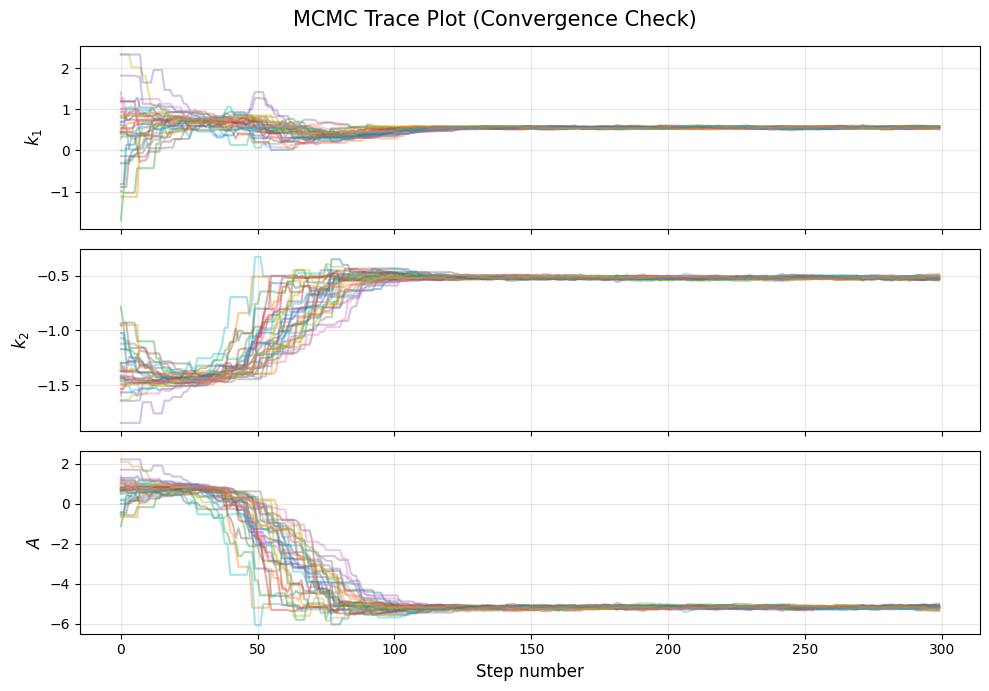

In [45]:
# Plot parameter values versus steps (iterations)
def trace_plot(sampler):
    chain = sampler.get_chain()  # shape: (steps, walkers, ndim)
    nsteps, nwalkers, ndim = chain.shape

    labels = [r'$k_1$', r'$k_2$', r'$A$']

    fig, axes = plt.subplots(ndim, 1, figsize=(10, 7), sharex=True)

    for j in range(ndim):
        ax = axes[j]
        for i in range(nwalkers):
            ax.plot(chain[:, i, j], alpha=0.4)

        ax.set_ylabel(labels[j], fontsize=12)
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel("Step number", fontsize=12)
    fig.suptitle("MCMC Trace Plot (Convergence Check)", fontsize=15)

    plt.tight_layout()
    plt.show()

trace_plot(sampler)

Comment: At first, the change of value for parameters seems to be random. It uses "random walkers" to check which location that has the best outcome (decide based on the log-likelihood). As the algorithm advances the iteration, each parameter converges into a single value.

After running emcee, plot the original data with the best fit line calculated from the emcee. Comment on the plot. [1 pnt]

In [48]:
# Plot data and best-fit line
def plotter(sampler, logAge, logMstar, logMacc):
    plt.ion()
    fig, ax = plt.subplots(figsize=(8, 6))

    # Scatter plot with Mstar as color
    sc = ax.scatter(logAge, logMacc, c=Mstar, cmap='viridis', s=20, label='Data')

    # Add colorbar
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(r'Stellar Mass ($M_\odot$)',size=12)

    # Get flattened MCMC samples
    samples = sampler.get_chain(flat=True)

    # Draw random model realizations
    inds = np.random.randint(len(samples), size=100)
    for i in inds:
        theta = samples[i]
        y_model = model_mcmc(theta, logAge, logMstar)
        ax.plot(logAge, y_model, color="red", alpha=0.05)

    ax.set_title('log Age vs log Macc (mcmc)', fontsize=15)
    ax.set_xlabel('log Age', size=12)
    ax.set_ylabel(r'$\log \dot{M}\ (M_\odot\,\mathrm{yr}^{-1})$', size=12)
    ax.tick_params(axis='both', labelsize=11)
    #ax.legend()

    #plt.show()

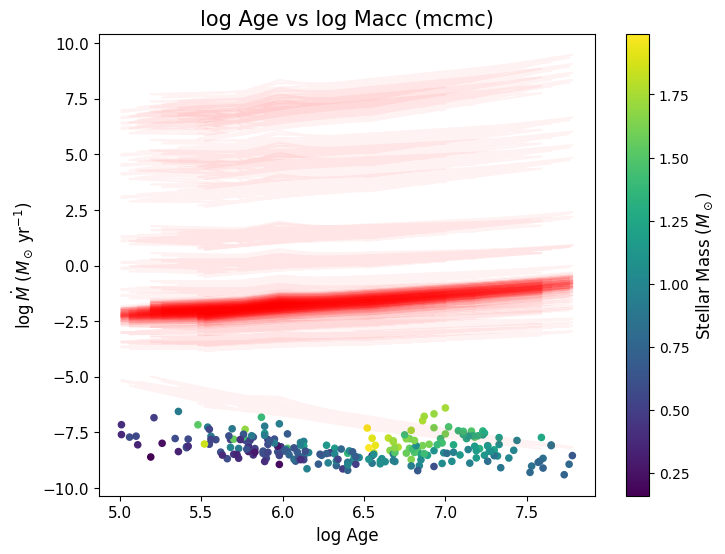

In [49]:
plotter(sampler, logAge, logMstar, logMacc)

Comments: The result does not really represent the real data for this case. The result are scatttred around, but there is a region where the density of the result is highest, which is indicated by redder area.

Finally, use the original data, its errors, and the emcee model data to calculate $\chi^{2}$ and $\chi^{2}_{v}$. Comment on the results. [1 pnt]

In [51]:
# Calculate chi-squared
samples = sampler.get_chain(flat=True)
log_prob = sampler.get_log_prob(flat=True)
best_theta = samples[np.argmax(log_prob)]

y_model = model_mcmc(best_theta, logAge, logMstar)
chi_mcmc = np.sum(((logMacc - y_model) / logMaccErr) ** 2)

# Calculate reduced chi-squared
N_mcmc = len(logMacc)
p_mcmc = 3
chi_red_mcmc = chi_mcmc / (N_mcmc - p_mcmc)

#chi_mcmc
print("Chi-square:", chi_mcmc)
print("Reduced Chi-square:", chi_red_mcmc)

#“The reduced chi-square is significantly greater than 1, 
# suggesting the model does not fully capture the data trends or that the uncertainties are underestimated.”
# model too simple
# missing physics
# underestimated errors

Chi-square: 1062491.821693142
Reduced Chi-square: 4599.531695641307


Comments: The value of $\chi_\nu^2$ is very huge, meaning that the model that is built here is very bad. One indication is that the model does not represent the whole physics that is actually involved in the discussion. Here, we only have 2 variables (stellar mass and age) that might affect the accretion rate of the star. In reality, there might be hidden variables such as metallicity that can affect the accretion. Also, linear model is likely incorrect for this case, so that we need to apply different model.